In [ ]:
# Prathmesh Durge, 23070521109

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D


In [7]:

# Load MNIST
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize and reshape
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)


In [8]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, 3, activation="relu", padding="same")(input_img)
x = MaxPooling2D(2, padding="same")(x)
x = Conv2D(16, 3, activation="relu", padding="same")(x)
encoded = MaxPooling2D(2, padding="same")(x)

# Decoder
x = Conv2D(16, 3, activation="relu", padding="same")(encoded)
x = UpSampling2D(2)(x)
x = Conv2D(32, 3, activation="relu", padding="same")(x)
x = UpSampling2D(2)(x)
decoded = Conv2D(1, 3, activation="sigmoid", padding="same")(x)

# Autoencoder
autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)


In [9]:

# Train
autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, x_test)
)

# Reconstruction
reconstructed = autoencoder.predict(x_test)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.1203 - val_loss: 0.0795
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0770 - val_loss: 0.0742
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0740 - val_loss: 0.0724
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0724 - val_loss: 0.0713
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0714 - val_loss: 0.0703
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0706 - val_loss: 0.0696
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0699 - val_loss: 0.0690
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0694 - val_loss: 0.0688
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0690 - val_loss: 0.0684
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0686 - val_loss: 0.0679
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


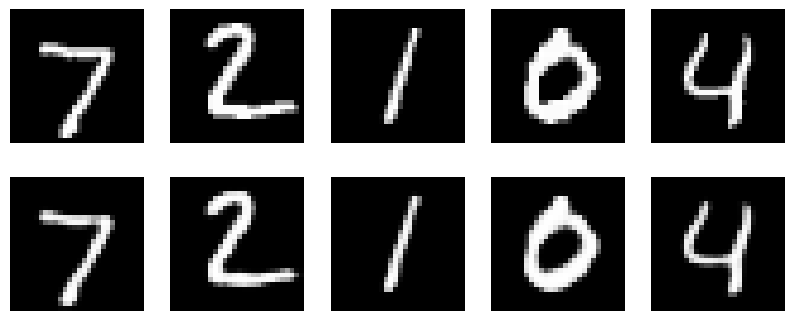

In [10]:

# Compare original and reconstructed images
plt.figure(figsize=(10, 4))

for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.show()